In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Imports OK")

Imports OK


FileNotFoundError: [Errno 2] No such file or directory: '../img/dataset_distribution.png'

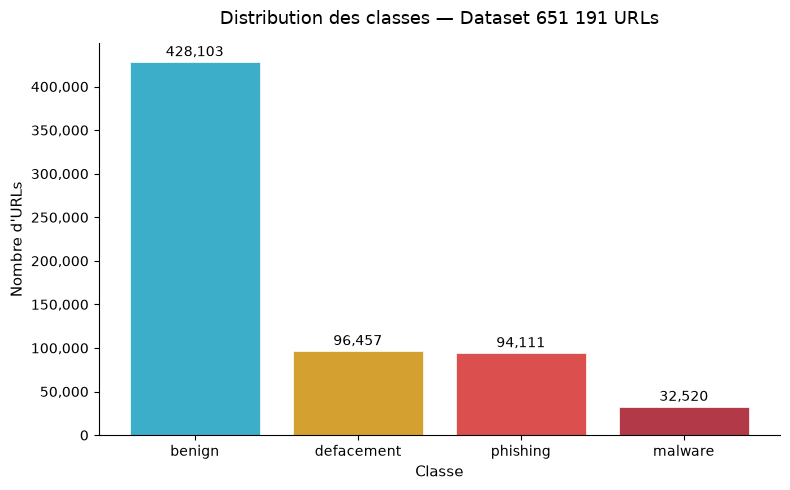

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['benign', 'defacement', 'phishing', 'malware']
values = [428103, 96457, 94111, 32520]
colors = ['#3DAECA', '#D4A030', '#DC4F4F', '#B23A48']
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Distribution des classes — Dataset 651 191 URLs', fontsize=13, pad=14)
ax.set_xlabel('Classe', fontsize=11)
ax.set_ylabel("Nombre d'URLs", fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../img/dataset_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
df = pd.read_csv('../data/malicious_phish.csv')
print(df.shape)
print(df.head())
print(df['type'].value_counts())

In [ ]:
# Convertir en classification binaire : 0 = benign, 1 = malicious
df['label'] = df['type'].apply(lambda x: 0 if x == 'benign' else 1)

print(df['label'].value_counts())
print(f"\nTaux de malveillants : {df['label'].mean()*100:.1f}%")

In [ ]:
def extract_features(url):
    return {
        'length': len(url),
        'num_dots': url.count('.'),
        'num_hyphens': url.count('-'),
        'num_slashes': url.count('/'),
        'num_digits': sum(c.isdigit() for c in url),
        'num_at': url.count('@'),
        'num_percent': url.count('%'),
        'num_question': url.count('?'),
        'num_equal': url.count('='),
        'num_underscore': url.count('_'),
        'has_https': int(url.startswith('https')),
        'has_ip': int(any(part.isdigit() for part in url.split('.'))),
        'domain_length': len(url.split('/')[0]) if '/' in url else len(url),
        'path_length': len('/'.join(url.split('/')[1:])) if '/' in url else 0,
    }

print("Extraction des features en cours...")
features = df['url'].apply(extract_features)
X = pd.DataFrame(features.tolist())
y = df['label']

print(f"Features extraites : {X.shape}")
print(X.head())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Taille train : {X_train.shape}")
print(f"Taille test  : {X_test.shape}")

In [ ]:
print("Entraînement en cours...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Entraînement terminé !")

In [ ]:
y_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report :")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

In [ ]:
import joblib

joblib.dump(rf_model, '../models/rf_phishing_model.pkl')
print("Modèle sauvegardé dans models/rf_phishing_model.pkl")

In [ ]:
def predict_url(url):
    features = extract_features(url)
    features_df = pd.DataFrame([features])
    prediction = rf_model.predict(features_df)[0]
    probability = rf_model.predict_proba(features_df)[0]
    
    label = "🔴 MALICIOUS" if prediction == 1 else "🟢 BENIGN"
    confidence = max(probability) * 100
    
    print(f"URL        : {url}")
    print(f"Résultat   : {label}")
    print(f"Confiance  : {confidence:.1f}%")
    print("-" * 60)

# Test avec des URLs réelles
test_urls = [
    "google.com",
    "paypal-secure-login.free.fr/update@account?id=123",
    "github.com/scikit-learn/scikit-learn",
    "192.168.1.1/admin/steal?user=data&pass=123",
    "amazon.com/dp/B08N5WRWNW",
    "secure-bnpparibas-login.tk/verification/compte"
]

for url in test_urls:
    predict_url(url)

In [ ]:
from urllib.parse import urlparse

def extract_features_v2(url):
    try:
        # Normaliser le format
        if not url.startswith('http'):
            url = 'http://' + url
        
        parsed = urlparse(url)
        domain = parsed.netloc
        path = parsed.path
    except:
        domain = ''
        path = ''
    
    # TLDs suspects
    suspicious_tlds = ['.tk', '.ml', '.ga', '.cf', '.gq', '.free.fr', '.xyz', '.top']
    # Mots suspects dans le domaine
    suspicious_words = ['login', 'secure', 'update', 'verify', 'account', 
                       'banking', 'paypal', 'amazon', 'apple', 'microsoft']
    
    return {
        'length': len(url),
        'num_dots': url.count('.'),
        'num_hyphens': url.count('-'),
        'num_slashes': url.count('/'),
        'num_digits': sum(c.isdigit() for c in url),
        'num_at': url.count('@'),
        'num_percent': url.count('%'),
        'num_question': url.count('?'),
        'num_equal': url.count('='),
        'num_underscore': url.count('_'),
        'has_https': int(url.startswith('https')),
        'has_ip': int(any(part.isdigit() for part in domain.split('.'))),
        'domain_length': len(domain),
        'path_length': len(path),
        'has_suspicious_tld': int(any(url.endswith(tld) or tld+'/' in url for tld in suspicious_tlds)),
        'has_suspicious_word': int(any(word in domain.lower() for word in suspicious_words)),
        'num_subdomains': len(domain.split('.')) - 2 if len(domain.split('.')) > 2 else 0,
        'has_at_in_url': int('@' in url),
    }

# Réentraîner avec les nouvelles features
print("Extraction des nouvelles features...")
features_v2 = df['url'].apply(extract_features_v2)
X_v2 = pd.DataFrame(features_v2.tolist())
y_v2 = df['label']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42
)

print(f"Nouvelles features : {X_v2.shape[1]}")
print("Entraînement du nouveau modèle...")
rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_v2.fit(X_train_v2, y_train_v2)
print("Terminé !")

In [ ]:
# Évaluation
y_pred_v2 = rf_model_v2.predict(X_test_v2)
print("=== Random Forest V2 ===")
print(f"Accuracy : {accuracy_score(y_test_v2, y_pred_v2)*100:.2f}%")
print("\nClassification Report :")
print(classification_report(y_test_v2, y_pred_v2, target_names=['Benign', 'Malicious']))

# Test URLs
print("\n=== Test URLs ===\n")
def predict_url_v2(url):
    features = extract_features_v2(url)
    features_df = pd.DataFrame([features])
    prediction = rf_model_v2.predict(features_df)[0]
    probability = rf_model_v2.predict_proba(features_df)[0]
    
    label = "🔴 MALICIOUS" if prediction == 1 else "🟢 BENIGN"
    confidence = max(probability) * 100
    
    print(f"URL        : {url}")
    print(f"Résultat   : {label}")
    print(f"Confiance  : {confidence:.1f}%")
    print("-" * 60)

test_urls = [
    "google.com",
    "paypal-secure-login.free.fr/update@account?id=123",
    "github.com/scikit-learn/scikit-learn",
    "192.168.1.1/admin/steal?user=data&pass=123",
    "amazon.com/dp/B08N5WRWNW",
    "secure-bnpparibas-login.tk/verification/compte"
]

for url in test_urls:
    predict_url_v2(url)

In [ ]:
joblib.dump(rf_model_v2, '../models/rf_phishing_model_v2.pkl')
print("Modèle v2 sauvegardé !")